In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("data_processed/btc_5m_2026-05-03.csv")
df["startDate"] = pd.to_datetime(df["startDate"], utc=True)
df["endDate"]   = pd.to_datetime(df["endDate"],   utc=True)
df["p_up"]      = df["p_up"].astype(float)
df["p_down"]    = df["p_down"].astype(float)
df["outcome"]   = (df["p_up"] >= 0.5).astype(int)   # 1 = Up, 0 = Down
df = df.sort_values("startDate").reset_index(drop=True)
df.head()

,slug,startDate,endDate,p_up,p_down,outcome
0,btc-updown-5m-1777766400,2026-05-02 00:09:18.006875+00:00,2026-05-03 00:05:00+00:00,1.0,0.0,1
1,btc-updown-5m-1777766700,2026-05-02 00:16:07.703427+00:00,2026-05-03 00:10:00+00:00,0.0,1.0,0
2,btc-updown-5m-1777767000,2026-05-02 00:18:38.418282+00:00,2026-05-03 00:15:00+00:00,0.0,1.0,0
3,btc-updown-5m-1777767300,2026-05-02 00:23:53.983605+00:00,2026-05-03 00:20:00+00:00,1.0,0.0,1
4,btc-updown-5m-1777767600,2026-05-02 00:28:39.434744+00:00,2026-05-03 00:25:00+00:00,1.0,0.0,1


## 1. Basic counts

In [3]:
n      = len(df)
n_up   = int(df["outcome"].sum())
n_down = n - n_up

print(f"Total windows : {n}")
print(f"Up            : {n_up:>4}  ({n_up/n:.1%})")
print(f"Down          : {n_down:>4}  ({n_down/n:.1%})")

Total windows : 288
Up            :  132  (45.8%)
Down          :  156  (54.2%)


## 2. Transition matrix (momentum / mean-reversion)

In [4]:
df["next"] = df["outcome"].shift(-1)
trans = df.dropna(subset=["next"]).copy()
trans["next"] = trans["next"].astype(int)

label = {1: "Up", 0: "Down"}
matrix = pd.crosstab(
    trans["outcome"].map(label),
    trans["next"].map(label),
    normalize="index"
).rename_axis("current", axis=0).rename_axis("next", axis=1)

print("Transition probabilities (row=current, col=next):")
print(matrix.round(4))
print()
print(f"P(Up   | Up)   = {matrix.loc['Up',   'Up']:.4f}")
print(f"P(Down | Down) = {matrix.loc['Down', 'Down']:.4f}")
print(f"P(Up   | Down) = {matrix.loc['Down', 'Up']:.4f}")
print(f"P(Down | Up)   = {matrix.loc['Up',   'Down']:.4f}")

Transition probabilities (row=current, col=next):
next       Down      Up
current                
Down     0.5290  0.4710
Up       0.5606  0.4394

P(Up   | Up)   = 0.4394
P(Down | Down) = 0.5290
P(Up   | Down) = 0.4710
P(Down | Up)   = 0.5606


## 3. Streak analysis

In [5]:
def run_lengths(outcomes):
    streaks = []
    cur, length = outcomes[0], 1
    for o in outcomes[1:]:
        if o == cur:
            length += 1
        else:
            streaks.append((cur, length))
            cur, length = o, 1
    streaks.append((cur, length))
    return pd.DataFrame(streaks, columns=["direction", "length"])

runs = run_lengths(df["outcome"].tolist())
runs["label"] = runs["direction"].map({1: "Up", 0: "Down"})

print("Streak length distribution (count of runs):")
print(runs.groupby(["label", "length"]).size().unstack(fill_value=0).to_string())
print()
print(f"Max Up streak   : {runs[runs.direction==1]['length'].max()}")
print(f"Max Down streak : {runs[runs.direction==0]['length'].max()}")
print(f"Mean streak len : {runs['length'].mean():.2f}")

Streak length distribution (count of runs):
length   1   2  3  4  5  6  7
label                        
Down    30  27  7  5  1  2  2
Up      36  26  6  4  2  0  0

Max Up streak   : 5
Max Down streak : 7
Mean streak len : 1.95


## 4. Autocorrelation (lags 1–10)

In [6]:
s = df["outcome"].astype(float)
lags = range(1, 11)
acs  = [s.autocorr(lag=l) for l in lags]

print("Serial autocorrelation:")
for lag, ac in zip(lags, acs):
    bar = "█" * int(abs(ac) * 40)
    sign = "+" if ac >= 0 else "-"
    print(f"  lag {lag:>2}: {sign}{abs(ac):.4f}  {bar}")

Serial autocorrelation:
  lag  1: -0.0316  █
  lag  2: -0.1550  ██████
  lag  3: +0.0676  ██
  lag  4: -0.0137  
  lag  5: -0.1033  ████
  lag  6: -0.0573  ██
  lag  7: +0.1039  ████
  lag  8: -0.0072  
  lag  9: -0.0391  █
  lag 10: +0.0011  


## 5. Chi-squared independence test

In [7]:
obs = pd.crosstab(trans["outcome"], trans["next"])
chi2, p_val, dof, _ = stats.chi2_contingency(obs)

print(f"Chi-squared = {chi2:.4f},  p = {p_val:.4f},  dof = {dof}")
if p_val < 0.05:
    print("→ Reject H0: consecutive outcomes are NOT independent (momentum/mean-reversion present)")
else:
    print("→ Fail to reject H0: consistent with independence (no detectable serial pattern)")

Chi-squared = 0.1733,  p = 0.6772,  dof = 1
→ Fail to reject H0: consistent with independence (no detectable serial pattern)


## 6. Time-of-day breakdown (UTC hours)

           p_up   n
hour_utc           
0         0.500  12
1         0.417  12
2         0.500  12
3         0.417  12
4         0.500  12
5         0.500  12
6         0.333  12
7         0.500  12
8         0.417  12
9         0.667  12
10        0.417  12
11        0.500  12
12        0.500  12
13        0.500  12
14        0.583  12
15        0.333  12
16        0.500  12
17        0.583  12
18        0.500  12
19        0.167  12
20        0.500  12
21        0.333  12
22        0.583  12
23        0.250  12


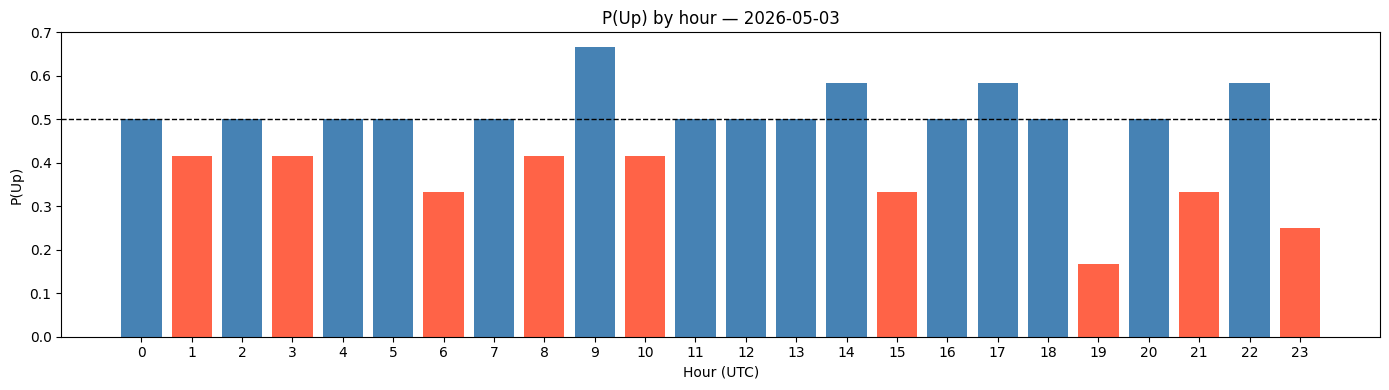

In [8]:
df["hour_utc"] = df["startDate"].dt.hour
hourly = df.groupby("hour_utc")["outcome"].agg(p_up="mean", n="count")

print(hourly.round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(hourly.index, hourly["p_up"], color=["steelblue" if v >= 0.5 else "tomato" for v in hourly["p_up"]])
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("P(Up)")
ax.set_title("P(Up) by hour — 2026-05-03")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## 7. Outcome timeline

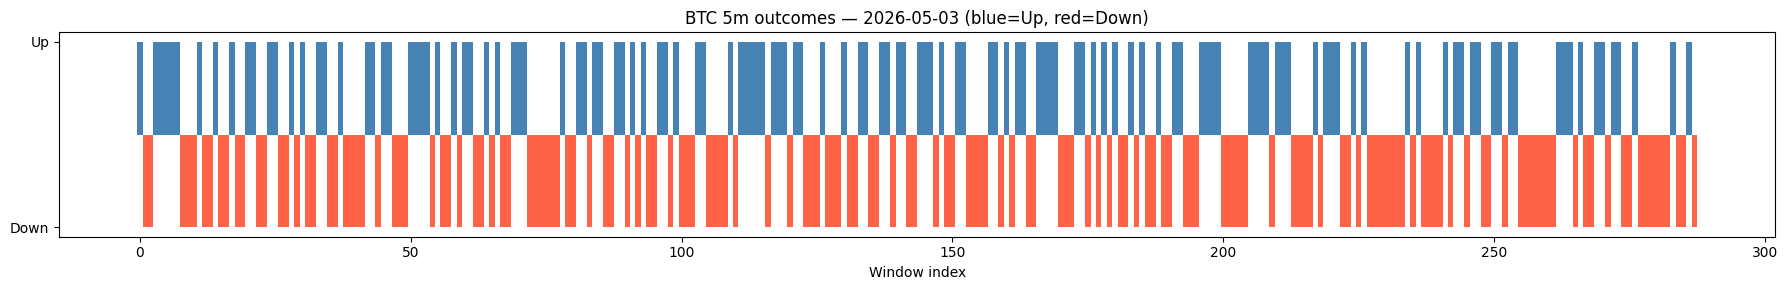

In [9]:
fig, ax = plt.subplots(figsize=(18, 3))
colors = ["steelblue" if o == 1 else "tomato" for o in df["outcome"]]
ax.bar(df.index, df["outcome"].map({1: 1, 0: -1}), color=colors, width=1)
ax.set_xlabel("Window index")
ax.set_yticks([-1, 1])
ax.set_yticklabels(["Down", "Up"])
ax.set_title("BTC 5m outcomes — 2026-05-03 (blue=Up, red=Down)")
plt.tight_layout()
plt.show()